In [20]:
import os
import pandas as pd
# use polars when using very large dataframes as polars is faster than pandas
import polars as pl

import seaborn as sns

# use pickle to save and load data objects (when saving a df using pickle, you save more information)
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from itertools import product


# With the ic() method you can print something that is between the brackets and automatically also print its name
from icecream import ic


In [21]:
# Read the Parquet file
df_scoped_pl = pl.read_parquet("C:/Users/jasmi/Documents/2025_Data_analyse/2025_03_Group_project_Supermarket/Data/data/df_scope.parquet")
df_scoped = df_scoped_pl.to_pandas()
print(f'the number of columns is {len(df_scoped.columns)}')

# Display column names, their data types, and the number of unique values:
print("Column Names and Data Types are:")
for column in df_scoped.columns:
 print(f"{column} datatype is: {df_scoped[column].dtype}")
 print(f'The number of unique values of {column} is: {len(df_scoped[column].unique())}')

the number of columns is 24
Column Names and Data Types are:
id datatype is: int32
The number of unique values of id is: 1993256
store_nbr datatype is: int8
The number of unique values of store_nbr is: 8
item_nbr datatype is: float32
The number of unique values of item_nbr is: 231
unit_sales datatype is: float32
The number of unique values of unit_sales is: 328
onpromotion datatype is: object
The number of unique values of onpromotion is: 3
day datatype is: int8
The number of unique values of day is: 31
month datatype is: category
The number of unique values of month is: 56
family datatype is: category
The number of unique values of family is: 1
class datatype is: int16
The number of unique values of class is: 22
perishable datatype is: int8
The number of unique values of perishable is: 1
city datatype is: category
The number of unique values of city is: 3
state datatype is: category
The number of unique values of state is: 3
type_x datatype is: category
The number of unique values of 

## Group by Items and make a plot showing contribution to total sales

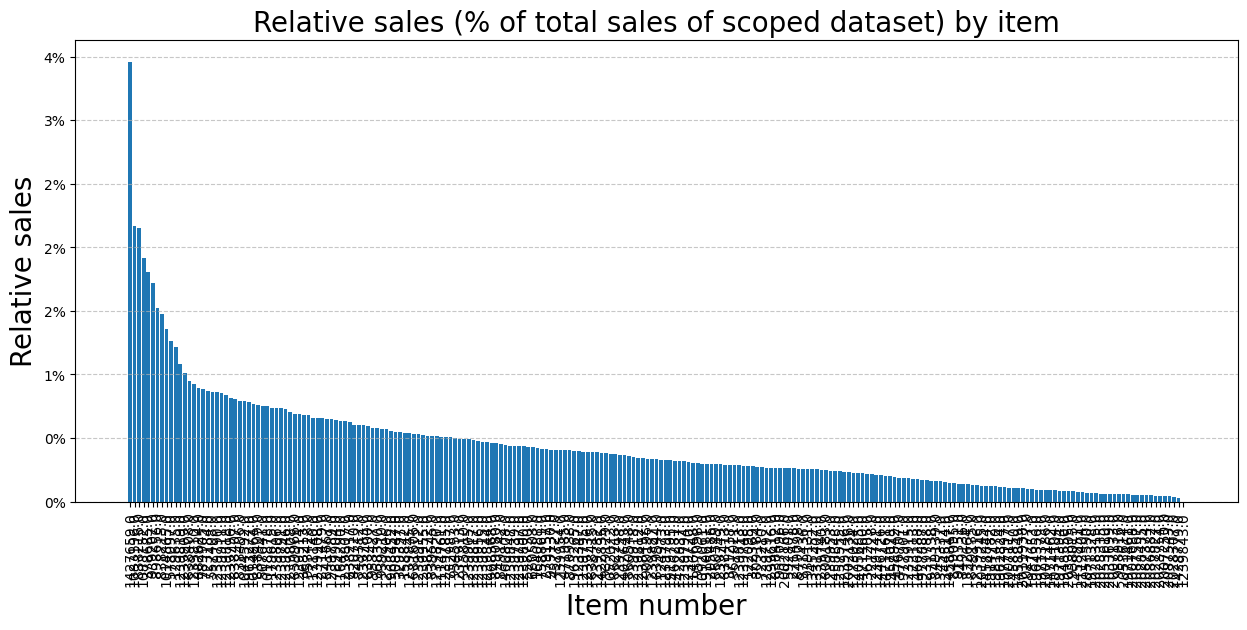

In [22]:
sales_by_item = df_scoped.groupby('item_nbr').agg({
    'unit_sales': 'sum',  # Sum the unit sales
    }).reset_index()


# Sort by 'unit_sales' descending
sales_by_item_sorted = sales_by_item.sort_values(by='unit_sales', ascending=False)

# Convert 'store_nbr' to categorical with explicit ordering
sales_by_item_sorted['item_nbr'] = pd.Categorical(
    sales_by_item_sorted['item_nbr'], categories=sales_by_item_sorted['item_nbr'], ordered=True)

# Calculate Relative sales
total_unit_sales = sales_by_item_sorted['unit_sales'].sum()
sales_by_item_sorted['relative sales'] = 100*sales_by_item_sorted['unit_sales'] / total_unit_sales

# Set 'store_nbr' as the index to preserve order
sales_by_item_sorted.set_index('item_nbr', inplace=True)

plt.figure(figsize=(15, 6))

# **Use column name instead of index for clarity**
plt.bar(sales_by_item_sorted.index.astype(str), sales_by_item_sorted['relative sales'])

   
# Improve readability
plt.xticks(rotation=90)
plt.xlabel("Item number", fontsize=20)
plt.ylabel("Relative sales", fontsize=20)
plt.title("Relative sales (% of total sales of scoped dataset) by item", fontsize=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Format y-axis labels to show percentages
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
plt.show()

## print the top 10 sold items and search for correlations among the numerical features

the top 10 most sold items are item_nbr
1427659.0    796396.0
1083196.0    499413.0
838216.0     495896.0
1083152.0    440636.0
378685.0     415008.0
939207.0     395114.0
898656.0     350660.0
838215.0     339042.0
1014865.0    311562.0
578097.0     290036.0
Name: unit_sales, dtype: float32


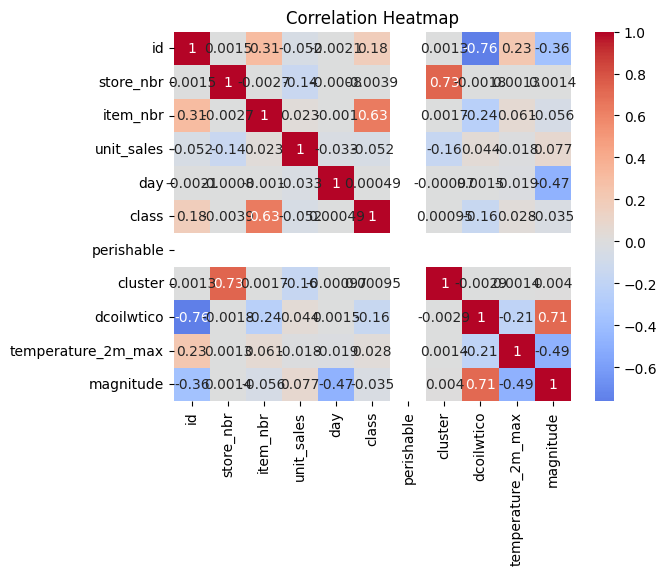

In [23]:
# The top 10 sold items are
top_10_items = sales_by_item_sorted.iloc[:10, 0]
print(f'the top 10 most sold items are {top_10_items}')

# Create a heatmap
corr = df_scoped.select_dtypes(include='number').corr()

# Plot heatmap
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


## Make a lineplot for produce in function of time and on a weekly basis

c:\Users\jasmi\Documents\2025_Data_analyse\2025_03_Group_project_Supermarket\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\jasmi\Documents\2025_Data_analyse\2025_03_Group_project_Supermarket\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\jasmi\Documents\2025_Data_analyse\2025_03_Group_project_Supermarket\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\jasmi\Documents\2025_Data_analyse\2025_03_Group_p

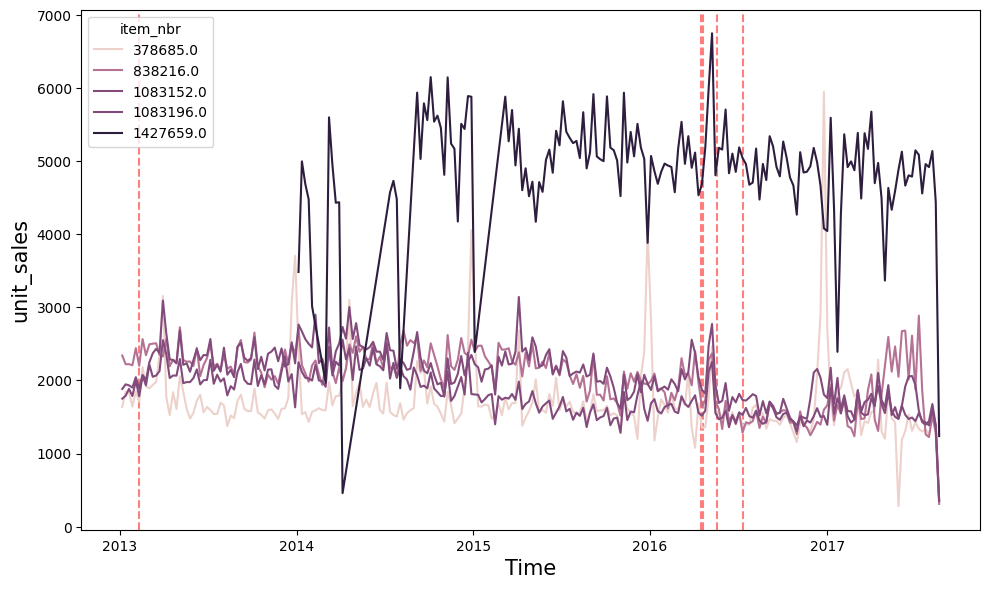

In [24]:
df_scoped['date'] = pd.to_datetime(df_scoped['date'])
magnitude_dates = df_scoped[df_scoped['magnitude'] > 6]['date'].unique()



top_10_items_df = df_scoped[df_scoped['item_nbr'].isin(top_10_items.index.astype('int64'))]
grouped_by_item_df = top_10_items_df.groupby(['item_nbr', 'date'])['unit_sales'].sum().reset_index()

weekly_df = grouped_by_item_df.groupby(['item_nbr', pd.Grouper(key='date', freq='W')]).sum().reset_index()


total_sales_by_item = weekly_df.groupby('item_nbr')['unit_sales'].sum().sort_values(ascending=False)
top3_item_ids = total_sales_by_item.head(3).index
top3_df = weekly_df[weekly_df['item_nbr'].isin(top3_item_ids)]

top5_item_ids = total_sales_by_item.head(5).index
top5_df = weekly_df[weekly_df['item_nbr'].isin(top5_item_ids)]

fig, ax1 = plt.subplots(figsize=(10, 6))
# Add vertical lines for magnitude dates
for date in magnitude_dates:
    plt.axvline(x=date, color='red', linestyle='--', alpha=0.5)
    
plt.ylabel("unit_sales", fontsize=15)
plt.xlabel("Time", fontsize=15)
sns.lineplot(data=top5_df, x='date', y='unit_sales', hue='item_nbr', ax=ax1)



#fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(10, 12))
#sns.lineplot(data=top6_df, x='date', y='unit_sales', hue='family', hue_order=['CLEANING', 'DAIRY', 'BREAD/BAKERY'], ax=ax2)
#ax2.set_title('Subtop Families (#4-6)')

#sns.lineplot(data=top10_df, x='date', y='unit_sales', hue='family', hue_order=['POULTRY', 'MEATS', 'PERSONAL CARE', 'DELI'], ax=ax3)
#ax3.set_title('Subtop Families (#7-10)')

#sns.lineplot(data=top13_df, x='date', y='unit_sales', hue='family', hue_order=['EGGS', 'FROZEN FOODS', 'HOME CARE'], ax=ax4)
#ax3.set_title('Subtop Families (#11-13)')

#sns.lineplot(data=top16_df, x='date', y='unit_sales', hue='family', hue_order=['PREPARED FOODS', 'LIQUOR,WINE,BEER', 'SEAFOOD'], ax=ax5)
#ax3.set_title('Subtop Families (#14-16)')

plt.tight_layout()
plt.show()
 

## 2016 zoom in on timeline with earthquake indications

c:\Users\jasmi\Documents\2025_Data_analyse\2025_03_Group_project_Supermarket\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\jasmi\Documents\2025_Data_analyse\2025_03_Group_project_Supermarket\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\jasmi\Documents\2025_Data_analyse\2025_03_Group_project_Supermarket\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\jasmi\Documents\2025_Data_analyse\2025_03_Group_p

<Axes: title={'center': '2016 unit sales evolution with earthquake indications'}, xlabel='Time', ylabel='unit_sales'>

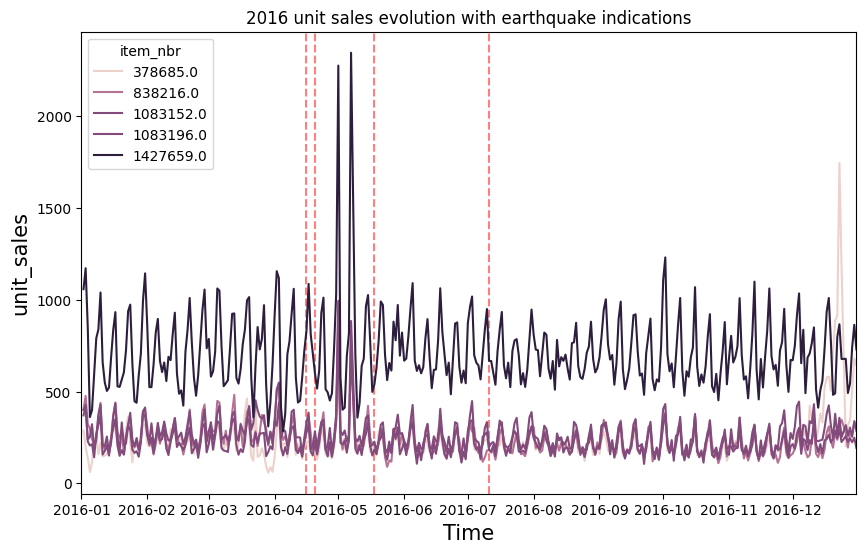

In [25]:
daily_df = grouped_by_item_df.groupby(['item_nbr', pd.Grouper(key='date', freq='D')]).sum().reset_index()
daily_2016_df = daily_df[(daily_df['date']>'2015-12-31')&(daily_df['date']<'2017-01-01') ]

top5_item_ids = total_sales_by_item.head(5).index
top5_daily_df = daily_2016_df[daily_2016_df['item_nbr'].isin(top5_item_ids)]


fig, ax1 = plt.subplots(figsize=(10, 6))
# Add vertical lines for magnitude dates
for date in magnitude_dates:
    plt.axvline(x=date, color='red', linestyle='--', alpha=0.5)
    
plt.ylabel("unit_sales", fontsize=15)
plt.xlabel("Time", fontsize=15)
plt.title('2016 unit sales evolution with earthquake indications')
from datetime import datetime
plt.xlim(datetime(2016, 1, 1), datetime(2016, 12, 31))
sns.lineplot(data=top5_daily_df, x='date', y='unit_sales', hue='item_nbr', ax=ax1)

## 2016 zoom in on timeline with payment day indications

c:\Users\jasmi\Documents\2025_Data_analyse\2025_03_Group_project_Supermarket\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\jasmi\Documents\2025_Data_analyse\2025_03_Group_project_Supermarket\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\jasmi\Documents\2025_Data_analyse\2025_03_Group_project_Supermarket\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\jasmi\Documents\2025_Data_analyse\2025_03_Group_p

<Axes: title={'center': '2016 unit sales evolution with payment indications'}, xlabel='Time', ylabel='unit_sales'>

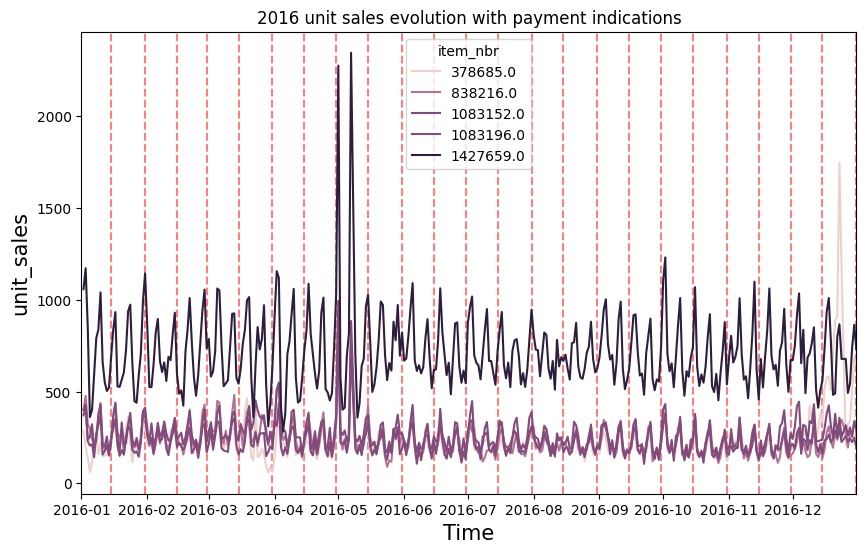

In [26]:
payment_dates = df_scoped[df_scoped['salary_payment'] == True]['date'].unique()

fig, ax1 = plt.subplots(figsize=(10, 6))
# Add vertical lines for payment dates
for date in payment_dates:
    plt.axvline(x=date, color='red', linestyle='--', alpha=0.5)
    
plt.ylabel("unit_sales", fontsize=15)
plt.xlabel("Time", fontsize=15)
plt.title('2016 unit sales evolution with payment indications')
from datetime import datetime
plt.xlim(datetime(2016, 1, 1), datetime(2016, 12, 31))
sns.lineplot(data=top5_daily_df, x='date', y='unit_sales', hue='item_nbr', ax=ax1)

## Zoom in on 2 months

c:\Users\jasmi\Documents\2025_Data_analyse\2025_03_Group_project_Supermarket\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\jasmi\Documents\2025_Data_analyse\2025_03_Group_project_Supermarket\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\jasmi\Documents\2025_Data_analyse\2025_03_Group_project_Supermarket\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\jasmi\Documents\2025_Data_analyse\2025_03_Group_p

<Axes: title={'center': '2016 Nov & Dec unit sales evolution with payment indications'}, xlabel='Time', ylabel='unit_sales'>

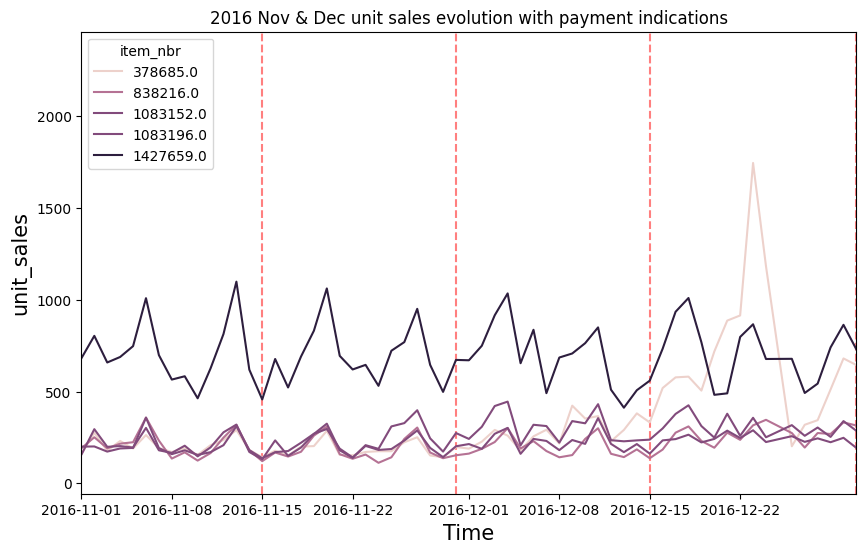

In [30]:
top5_daily_df = daily_2016_df[daily_2016_df['item_nbr'].isin(top5_item_ids)]

fig, ax1 = plt.subplots(figsize=(10, 6))
# Add vertical lines for payment dates
for date in payment_dates:
    plt.axvline(x=date, color='red', linestyle='--', alpha=0.5)
    
plt.ylabel("unit_sales", fontsize=15)
plt.xlabel("Time", fontsize=15)
plt.title('2016 Nov & Dec unit sales evolution with payment indications')
from datetime import datetime
plt.xlim(datetime(2016, 11, 1), datetime(2016, 12, 31))
sns.lineplot(data=top5_daily_df, x='date', y='unit_sales', hue='item_nbr', ax=ax1)